# Brain Mask Analysis - Segmentation Mask Volumetry

### Contact
- **Alexander R. Webber** (alexander.webber@fda.hhs.gov)
- **Seyed M. Kahaki** (seyed.kahaki@fda.hhs.gov)

---

Compares groups of NIfTI segmentation masks: it measures the physical volume of every mask, shows
center slices of a sample of cases side by side, and summarizes the per-group volume distributions.


## Input format

Groups are defined by glob patterns, so any directory layout works. A case is identified by the
directory names along its path, which is also how `excluded_cases` skips specific cases.

| Item | Details |
|---|---|
| **File type** | NIfTI (`.nii`, `.nii.gz`), any voxel grid and spacing |
| **Foreground** | Voxels `> 0`, except for the filenames listed in `inverted_mask_filenames` |
| **Volume** | `voxel count × voxel volume`, using the spacing in the NIfTI header, reported in cm³ |

### Conventional and inverted masks

Both mask families under these roots are handled by the same code path:

| Mask file | Meaning of positive voxels | Handling |
|---|---|---|
| `skull.nii.gz` | The skull itself - **foreground** | Voxels `> 0` are measured |
| `no_brain.nii.gz` | Everything that is *not* brain - **background** | Inverted automatically: voxels `<= 0` are measured |

Inversion is decided by filename through `inverted_mask_filenames`, which defaults to
`('no_brain.nii.gz',)`. Add any other background-encoded filename there.


## 1 · Imports


In [1]:
import os
import sys

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

from IPython.display     import display
from matplotlib          import pyplot as plt

from src.brain_pipeline  import run_mask_analysis


## 2 · Configuration

This is the only cell you need to edit. Each entry in `mask_analyses` becomes one independent
analysis with its own figures and tables - delete an entry to skip that mask family, or add one to
cover another.


In [2]:
REAL_ROOT  = (
    '/projects01/didsr-aiml/yeelamelim.thompson/SDDT/brain/segmentation/'
    'segmentation/outputs/second_attempt/topcow/rsna_aneurysm'
)
SYNTH_ROOT = (
    '/projects01/didsr-aiml/yeelamelim.thompson/SDDT/brain/segmentation/'
    'segmentation/outputs/first_attempt/topcow/26_06_25_17_05_batch_100'
)

# One entry per mask family. Names are used in figure titles and output filenames.
mask_analyses = {
    'Brain Mask': {
        'input_groups': {
            'Real'     : [f'{REAL_ROOT}/*/no_brain.nii.gz'],
            'Synthetic': [f'{SYNTH_ROOT}/*/no_brain.nii.gz'],
        },
    },

    'Skull Mask': {
        'input_groups': {
            'Real'     : [f'{REAL_ROOT}/*/intermediate/total_segmentator/skull.nii.gz'],
            'Synthetic': [f'{SYNTH_ROOT}/*/intermediate/total_segmentator/skull.nii.gz'],
        },
    },
}

shared_settings = {
    'excluded_cases': {
        'Real': {
            # '1.2.826.0.1.3680043.8.498.87794163393266428648659243169230666286',
            # '1.2.826.0.1.3680043.8.498.10935907012185032169927418164924236382',
        },
    },

    'num_display'     : 5,     
    'seed'            : 42,    
    'inspect_extremes': True,

    # 'group_colors'           : {'Real': '#007CBA', 'Synthetic': '#FF8C42'},
    # 'inverted_mask_filenames': ('no_brain.nii.gz',),
    # 'save_outputs'           : False,
}


## 3 · Run

Each analysis writes its figures, CSV tables, and text summary to
`data/notebook_outputs/brain_masks/`, prefixed with its name.


BRAIN MASK — VOLUMETRY
Found   61 real mask(s)
Found  100 synthetic mask(s)
Measured 161 mask(s); 0 failed.


findfont: Failed to find font weight semibold, now using 700.
findfont: Failed to find font weight semibold, now using 700.
findfont: Failed to find font weight semibold, now using 700.



SAMPLE AND VOXEL SUMMARY
----------------------------------------------------------------------------------
Group            N Cases    Inverted     Avg Voxel Vol (mm³)       Avg Voxel Count
----------------------------------------------------------------------------------
Real                  61          61                0.234919             4,318,116
Synthetic            100         100                1.000000               840,505
----------------------------------------------------------------------------------

VOLUME DISTRIBUTION SUMMARY (cm³ unless otherwise noted)
--------------------------------------------------------------------------------------------------------------------------------------------
Group               Mean    Median   Std Dev  Variance (cm⁶)       Min        Q1        Q3       Max       IQR     Range    CV (%)      Skew
----------------------------------------------------------------------------------------------------------------------------------------

findfont: Failed to find font weight semibold, now using 700.



Saved 7 output file(s) to /home/alexander.webber/programming/ScoreCard-Private/notebooks/data/notebook_outputs/brain_masks
SKULL MASK — VOLUMETRY
Found   63 real mask(s)
Found  100 synthetic mask(s)
Measured 163 mask(s); 0 failed.

SAMPLE AND VOXEL SUMMARY
----------------------------------------------------------------------------------
Group            N Cases    Inverted     Avg Voxel Vol (mm³)       Avg Voxel Count
----------------------------------------------------------------------------------
Real                  63           0                0.232157             3,999,214
Synthetic            100           0                1.000000             1,053,695
----------------------------------------------------------------------------------

VOLUME DISTRIBUTION SUMMARY (cm³ unless otherwise noted)
--------------------------------------------------------------------------------------------------------------------------------------------
Group               Mean    Median   Std Dev 

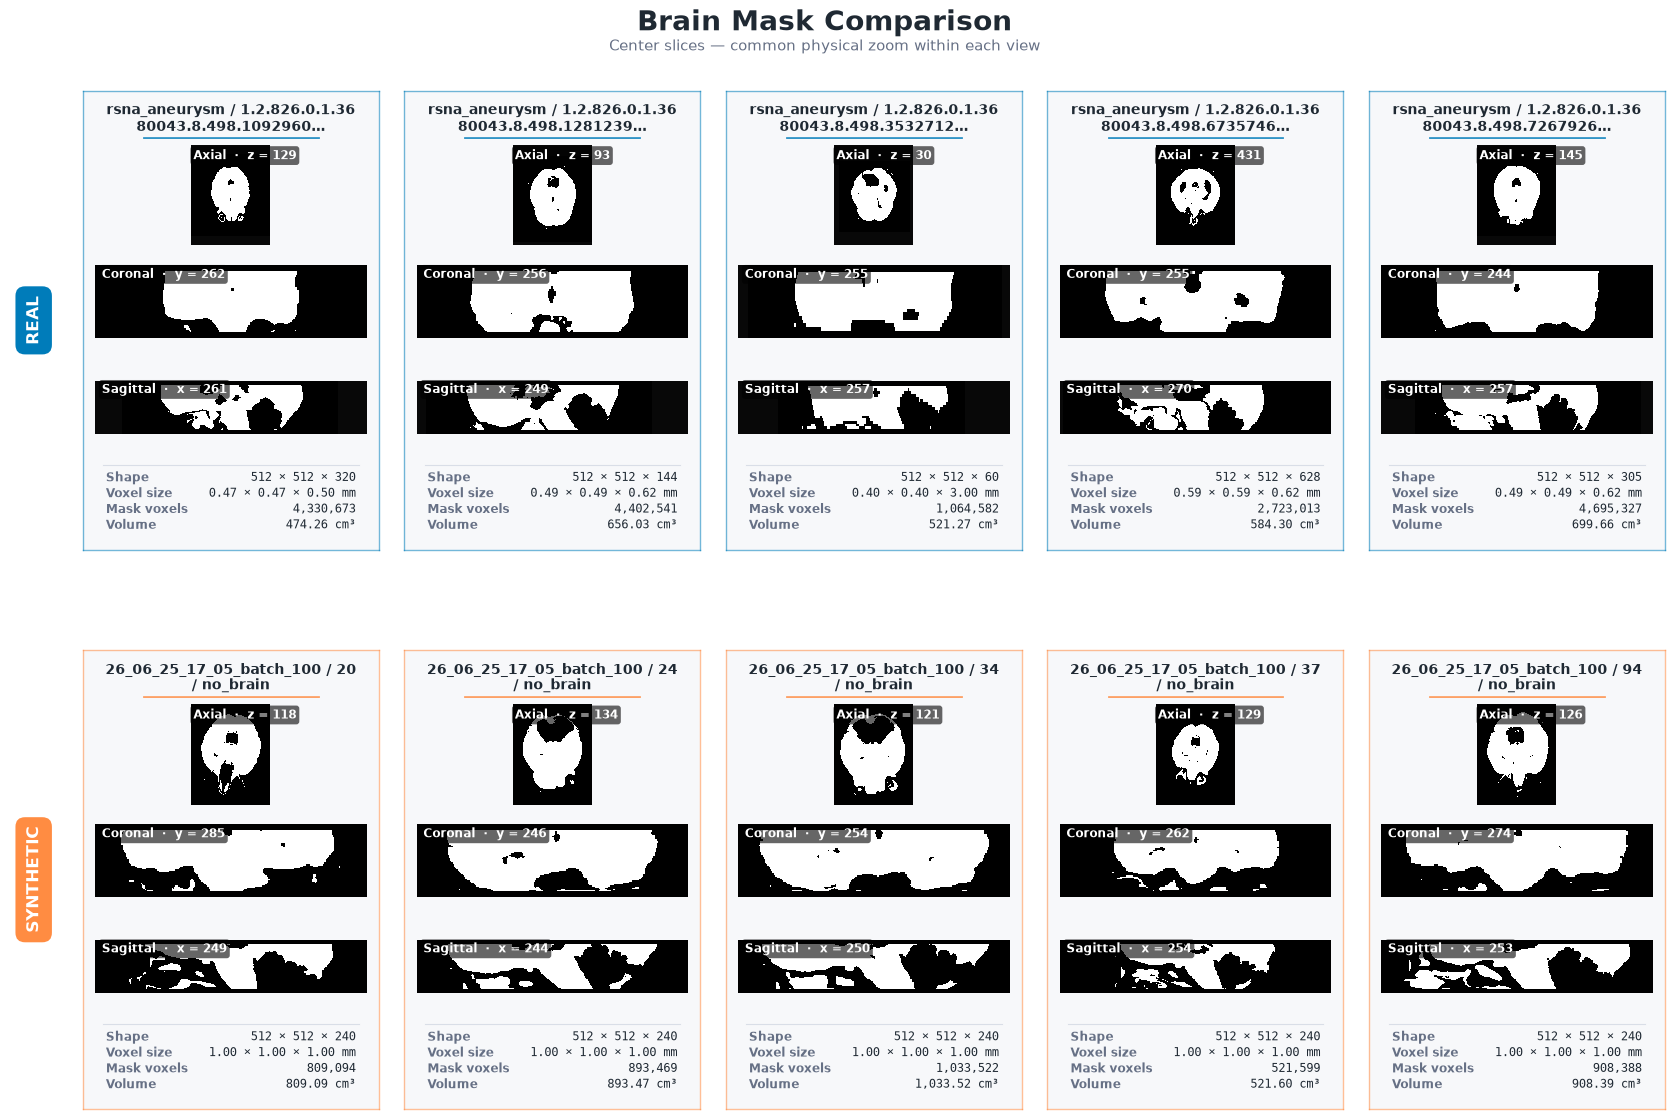

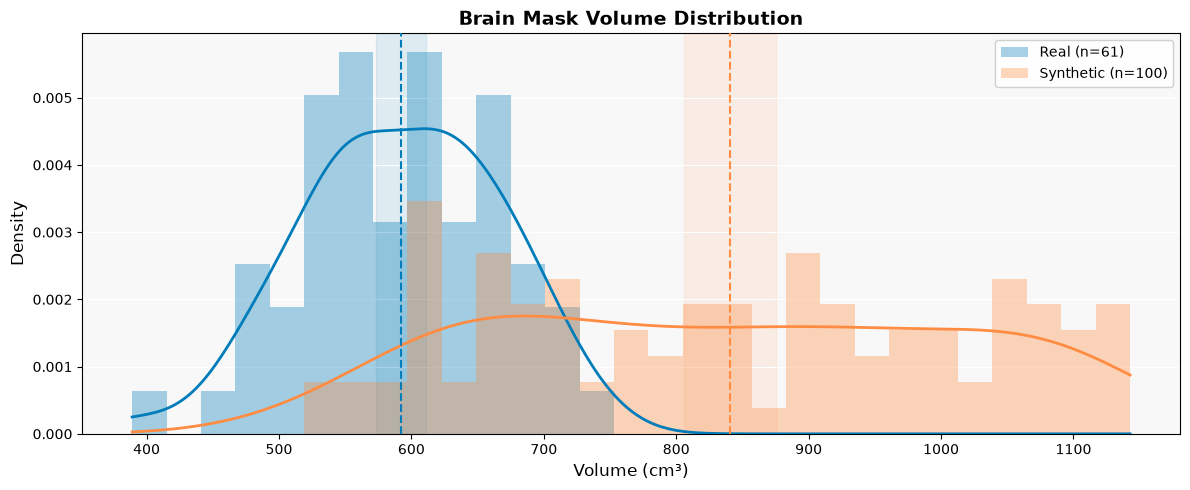

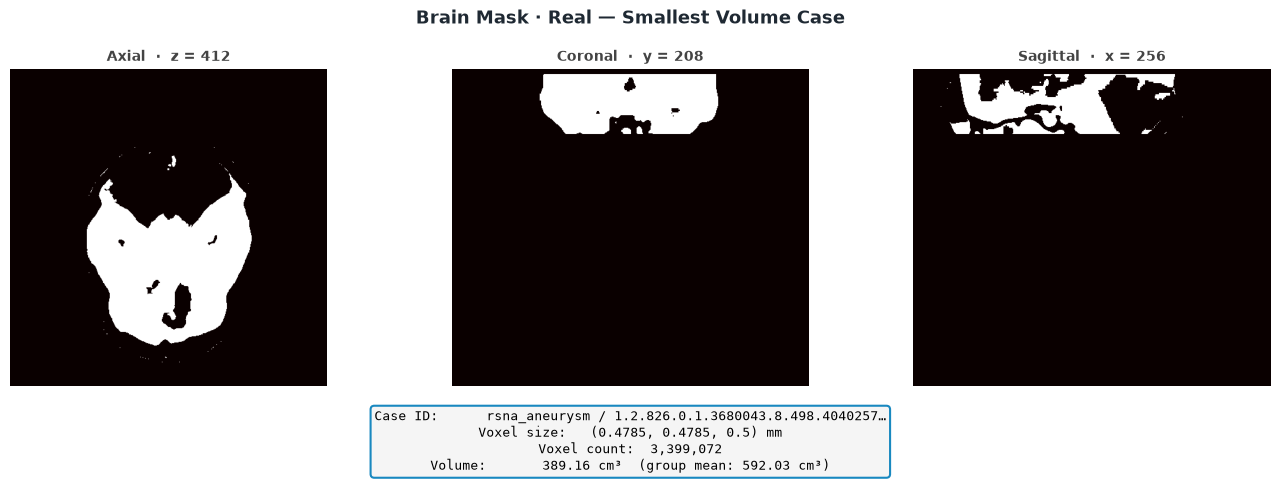

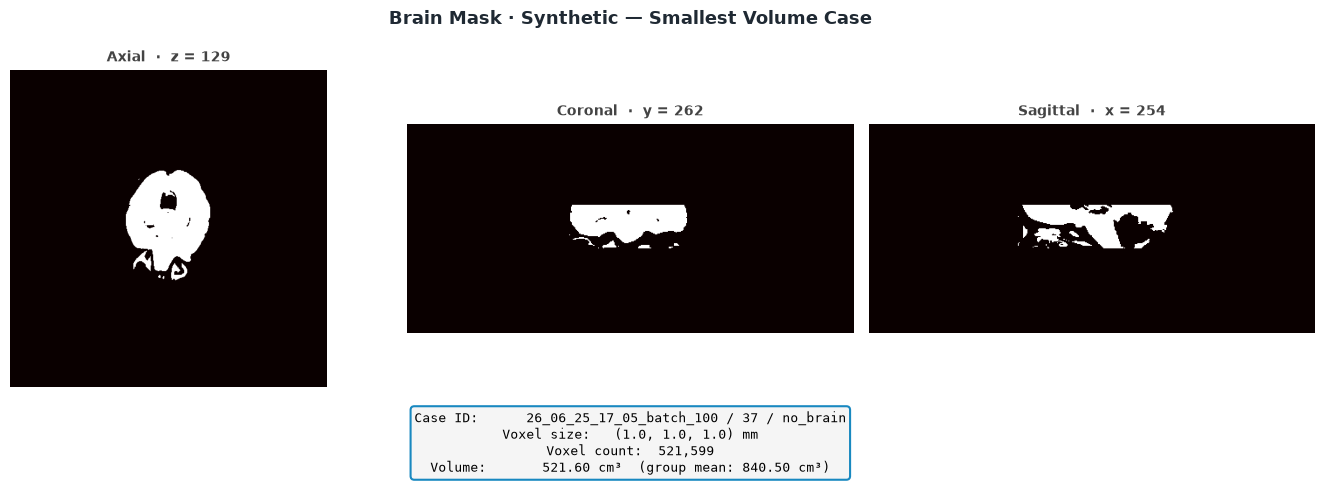

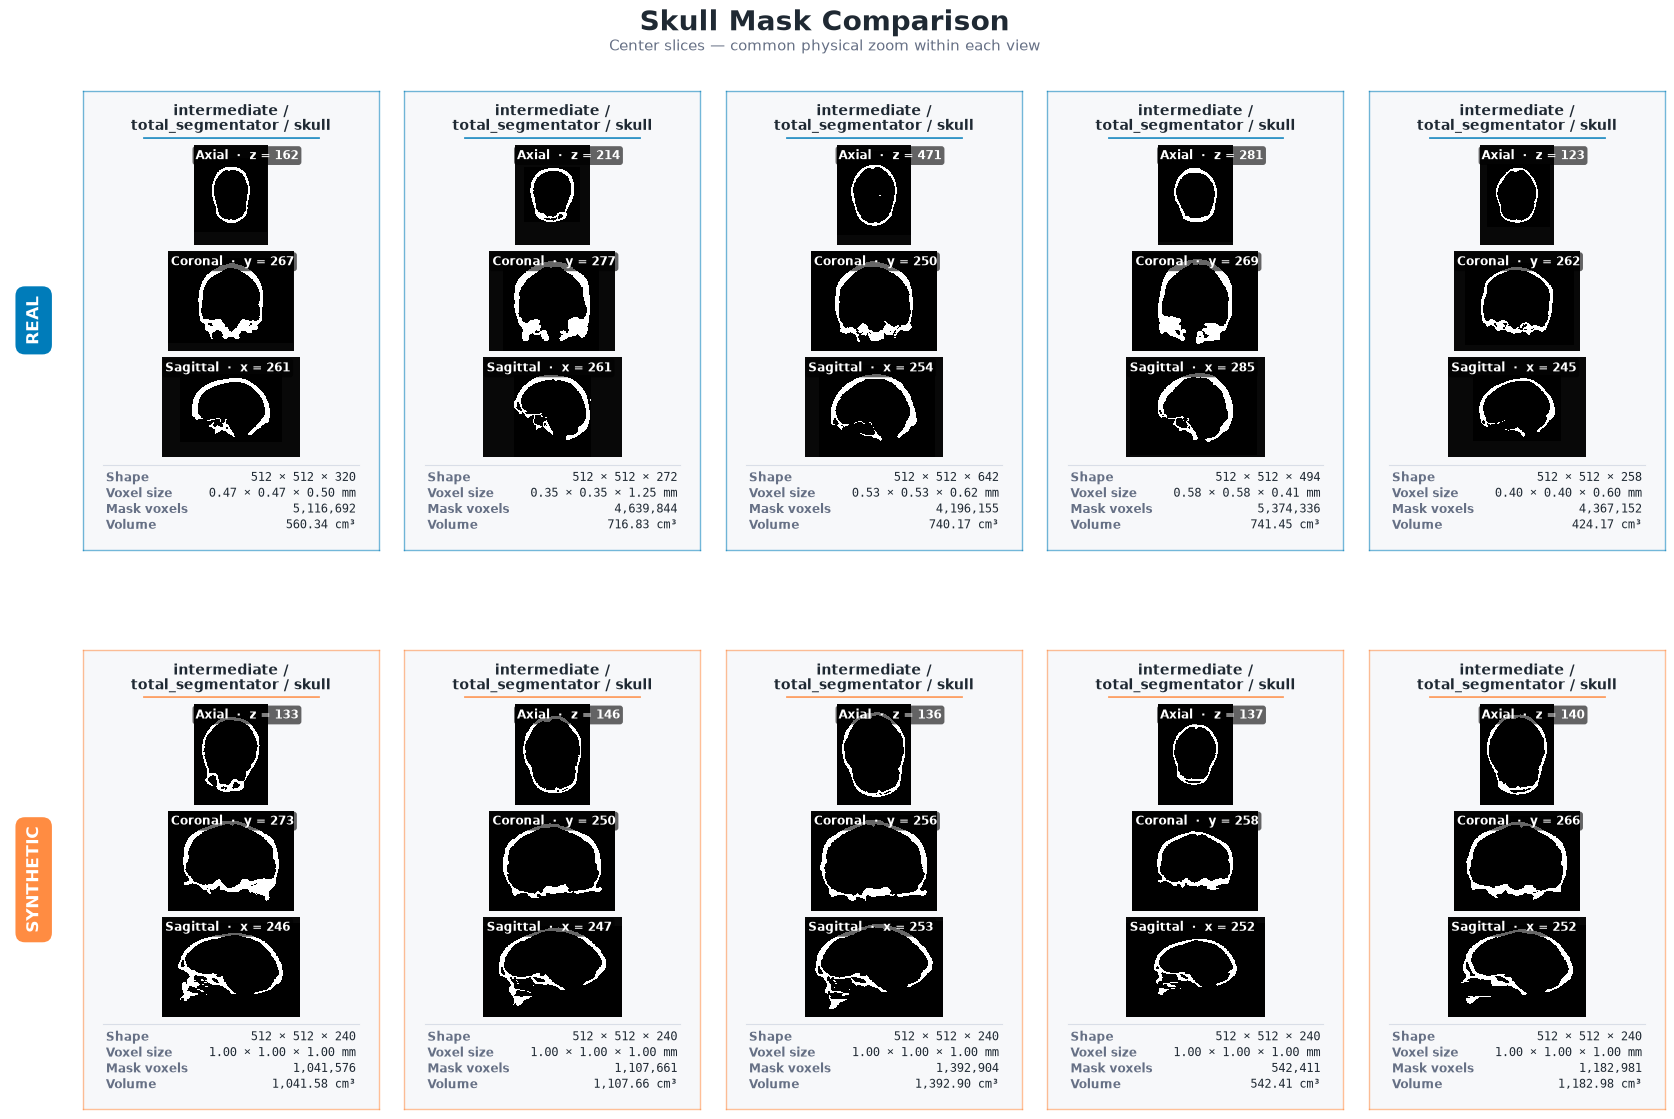

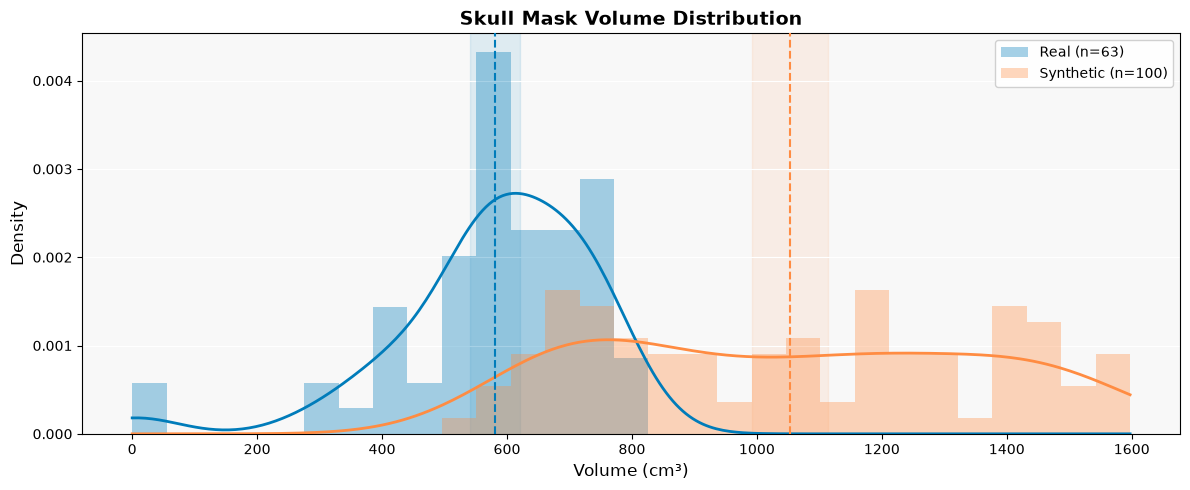

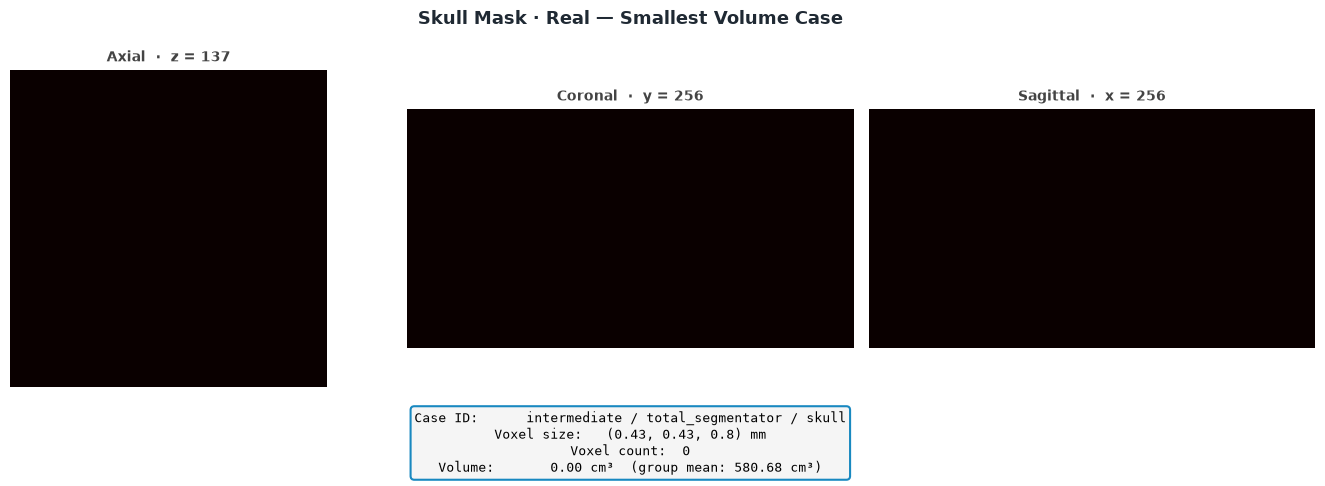

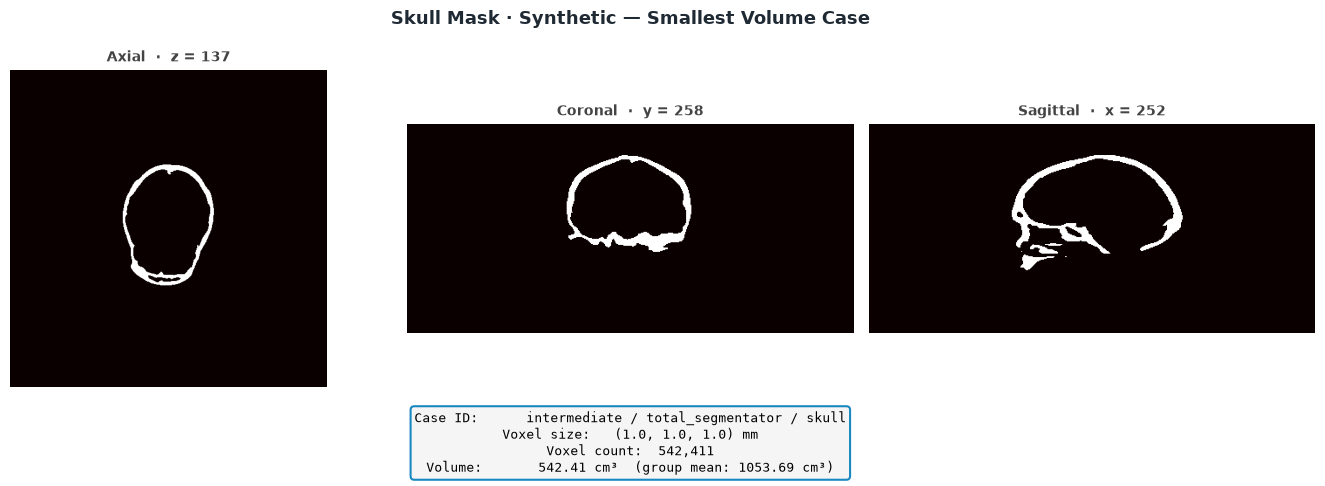

In [4]:
results = {
    name: run_mask_analysis(analysis_name=name, **settings, **shared_settings)
    for name, settings in mask_analyses.items()
}

## 4 · Results

- **Comparison grid** - center slices of the sampled cases, one row per group. Every panel of a
  given view shares one physical zoom window, so mask sizes can be compared directly across cards.
- **Volume distribution** - per-group histogram with a KDE curve, mean line, and shaded 95% CI.
- **Smallest-volume case** - a closer look at each group's smallest mask, which is where failed
  segmentations usually show up.

Summary columns: standard deviation and variance measure absolute spread; Q1/Q3/IQR describe the
middle 50% and resist outliers; CV expresses spread relative to the mean, which matters when groups
differ in average volume; skewness is positive for a longer right tail. Statistics needing more
cases than a group has are reported as `NA`.


--- Brain Mask · comparison ---


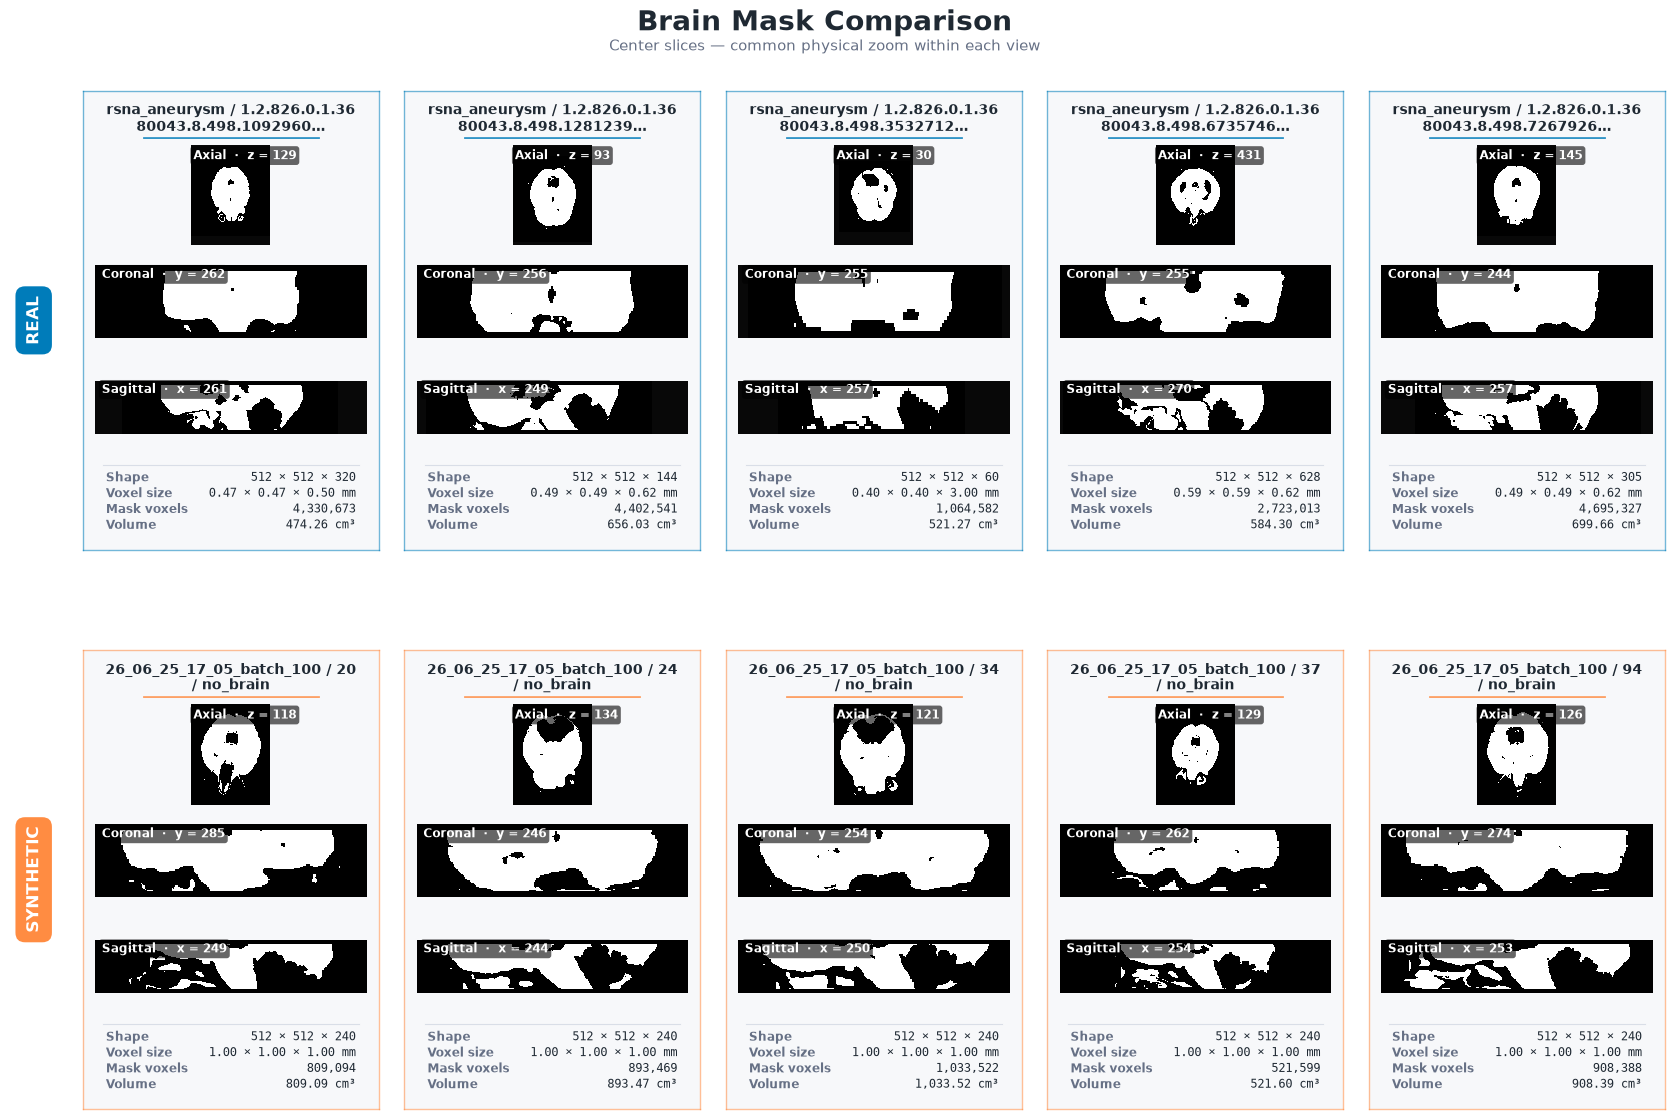

--- Brain Mask · volume_distribution ---


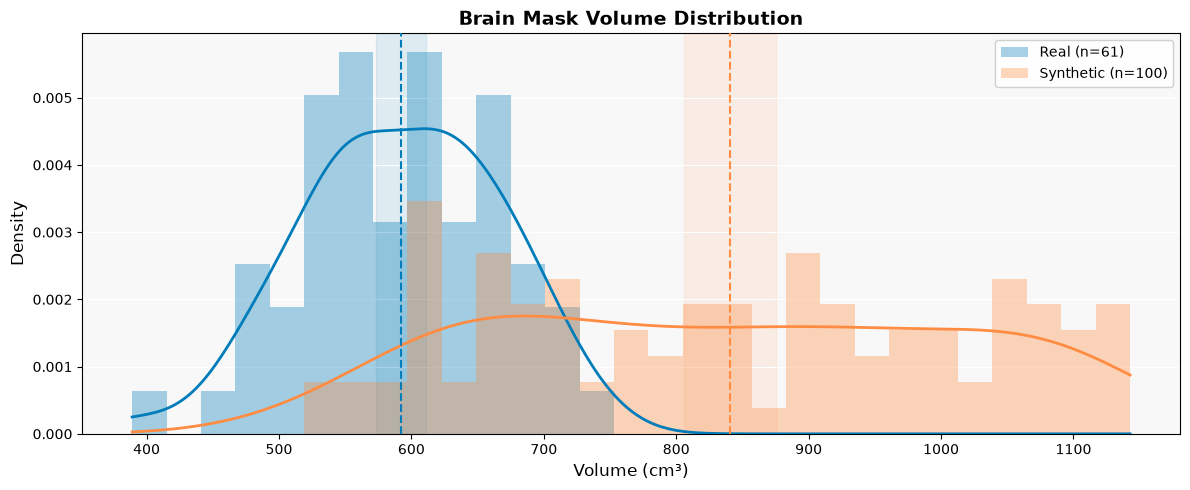

--- Brain Mask · smallest_Real ---


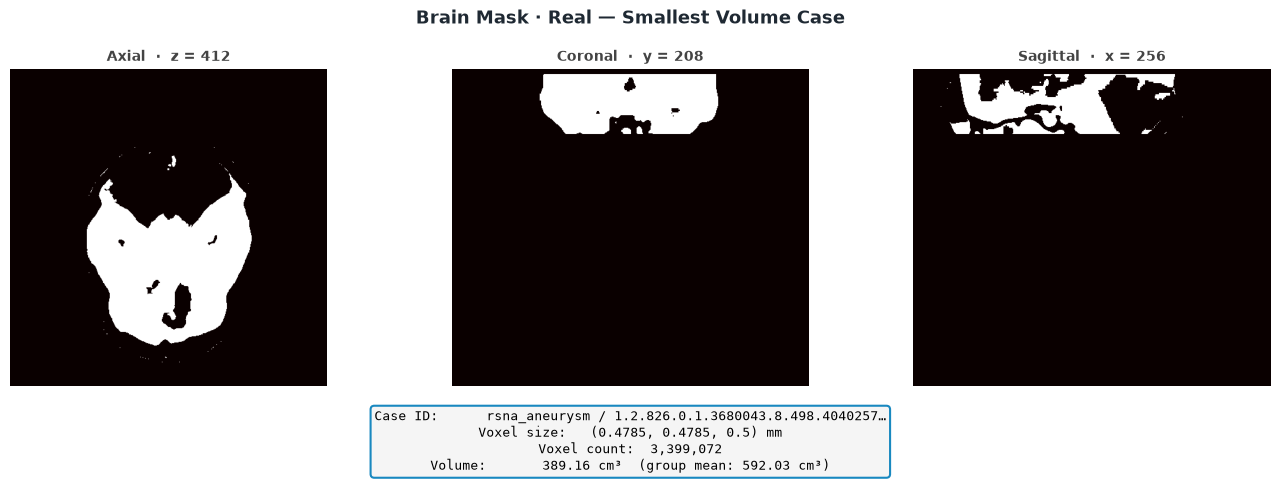

--- Brain Mask · smallest_Synthetic ---


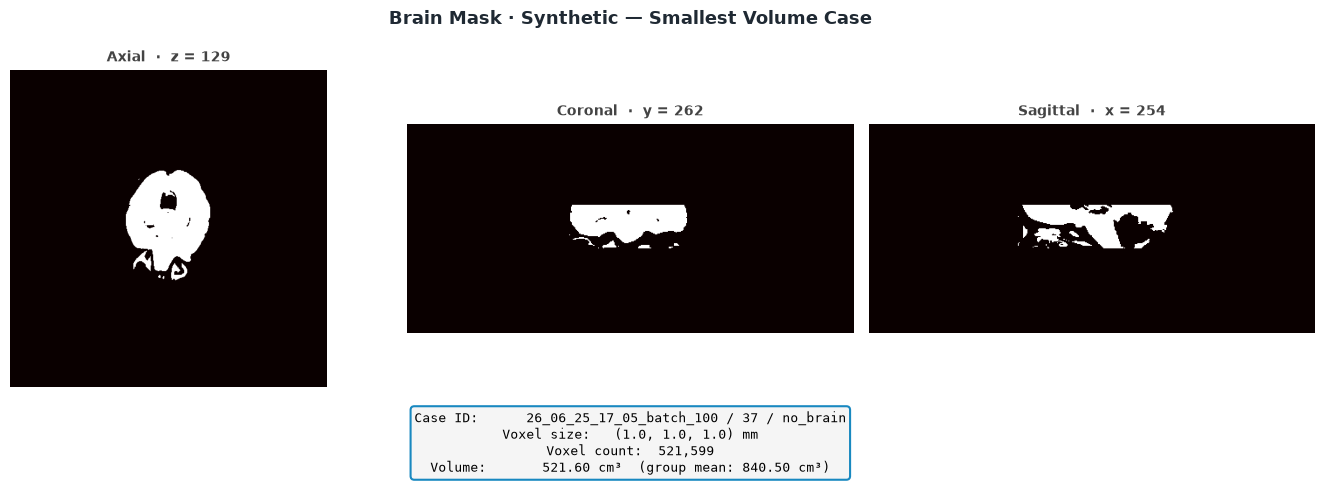

SAMPLE AND VOXEL SUMMARY
----------------------------------------------------------------------------------
Group            N Cases    Inverted     Avg Voxel Vol (mm³)       Avg Voxel Count
----------------------------------------------------------------------------------
Real                  61          61                0.234919             4,318,116
Synthetic            100         100                1.000000               840,505
----------------------------------------------------------------------------------

VOLUME DISTRIBUTION SUMMARY (cm³ unless otherwise noted)
--------------------------------------------------------------------------------------------------------------------------------------------
Group               Mean    Median   Std Dev  Variance (cm⁶)       Min        Q1        Q3       Max       IQR     Range    CV (%)      Skew
-----------------------------------------------------------------------------------------------------------------------------------------

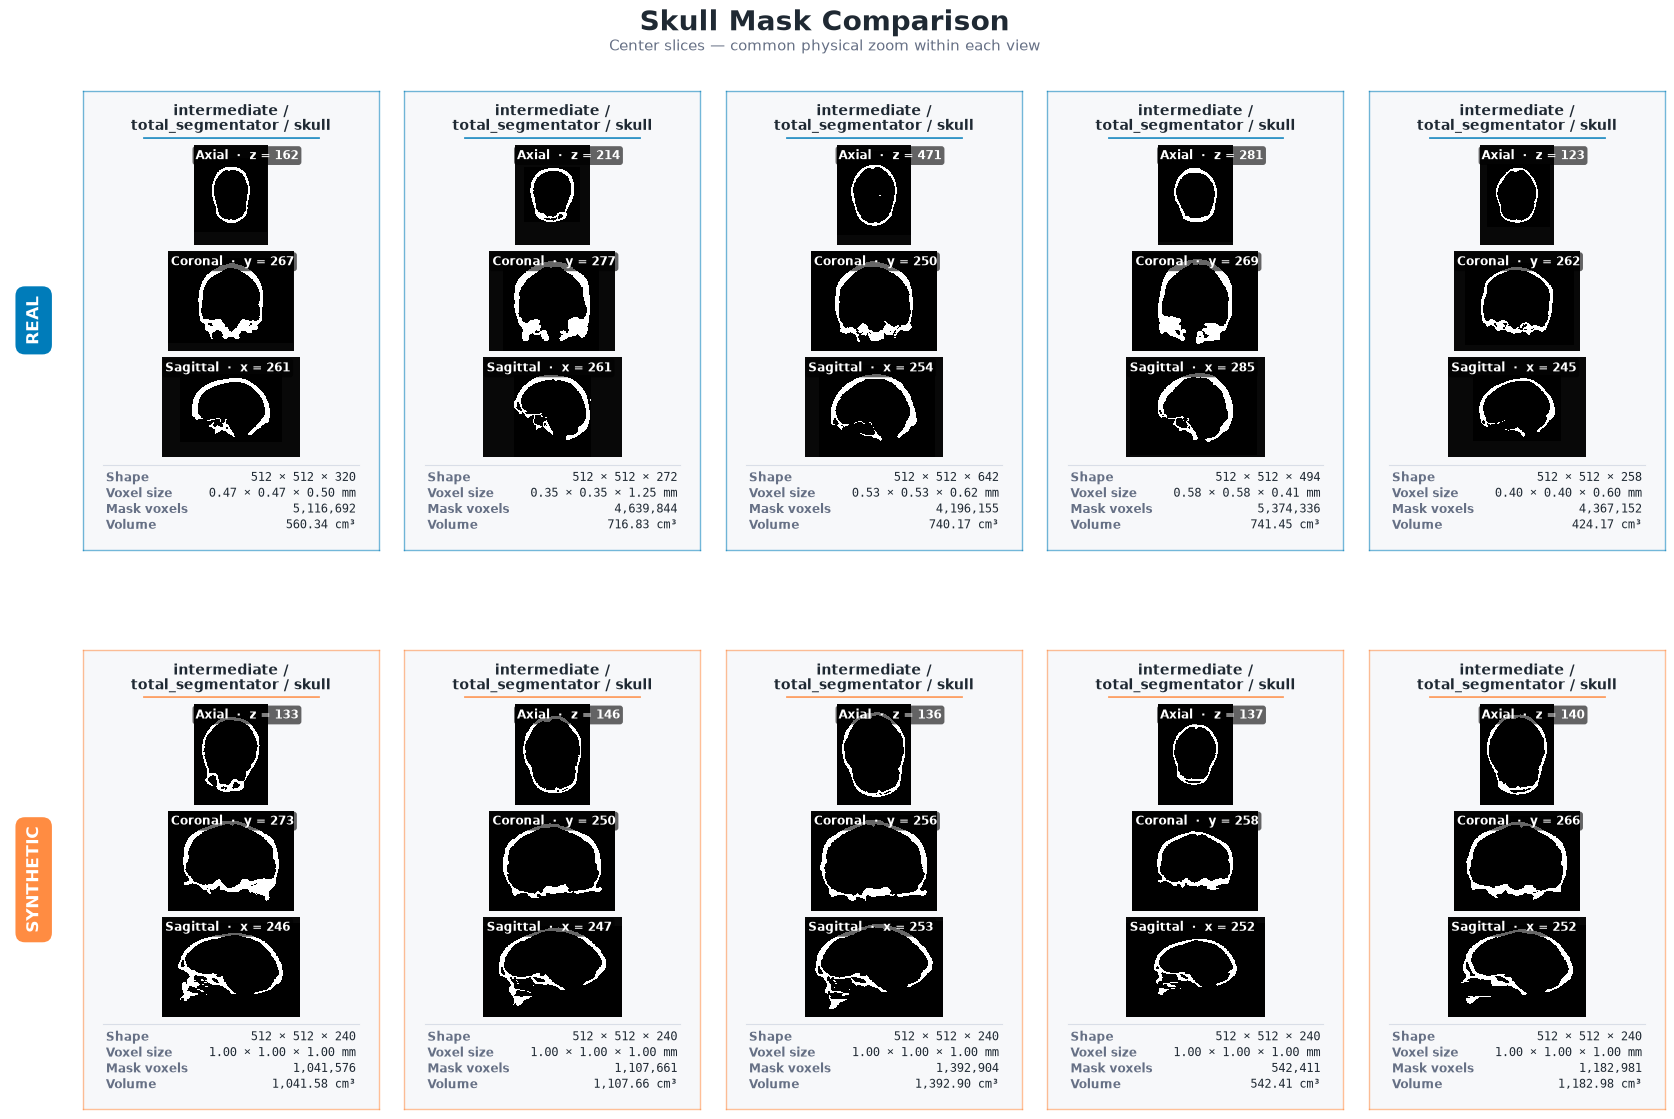

--- Skull Mask · volume_distribution ---


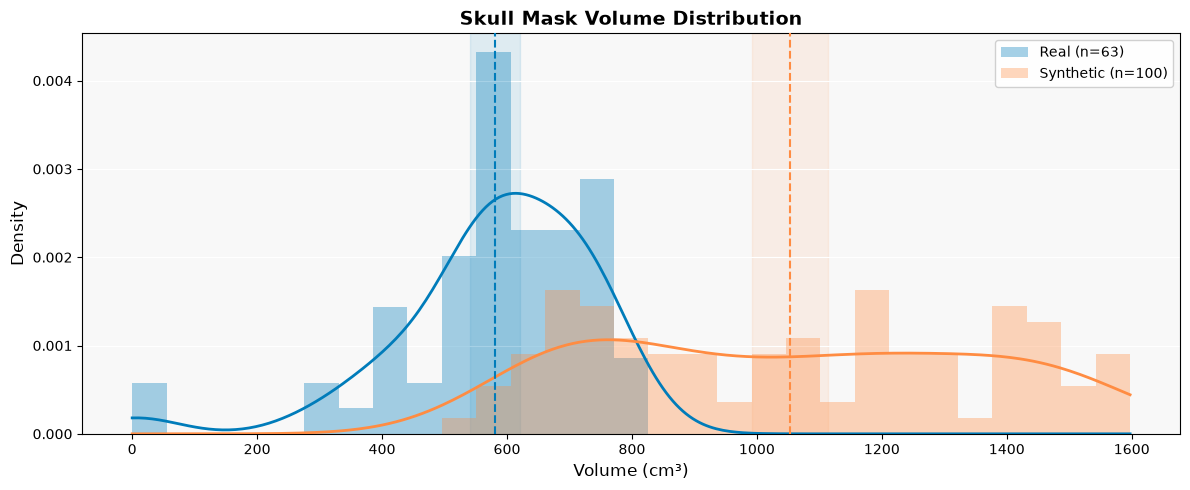

--- Skull Mask · smallest_Real ---


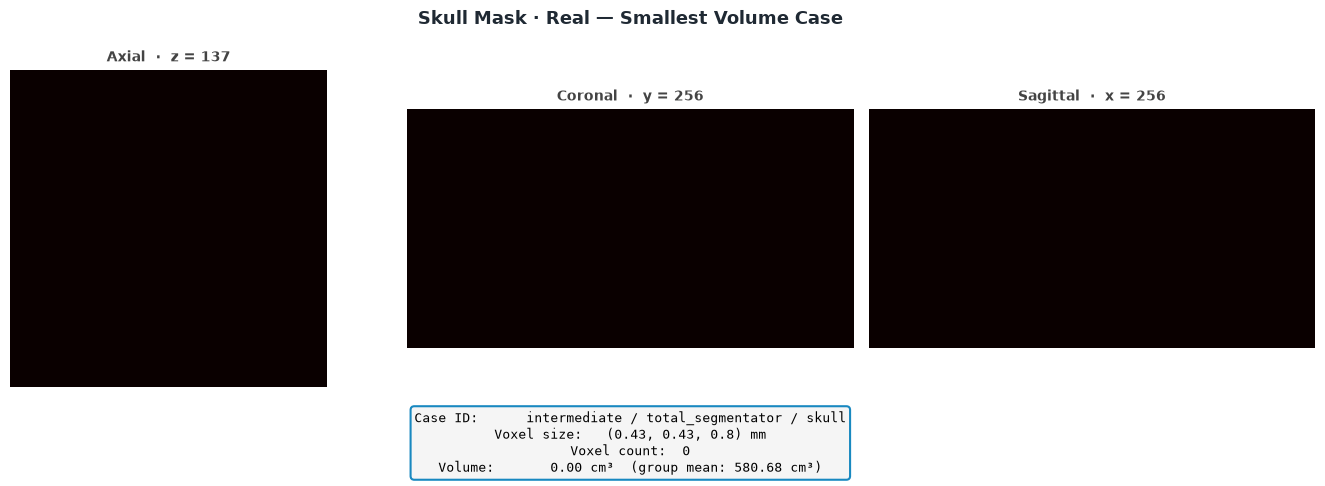

--- Skull Mask · smallest_Synthetic ---


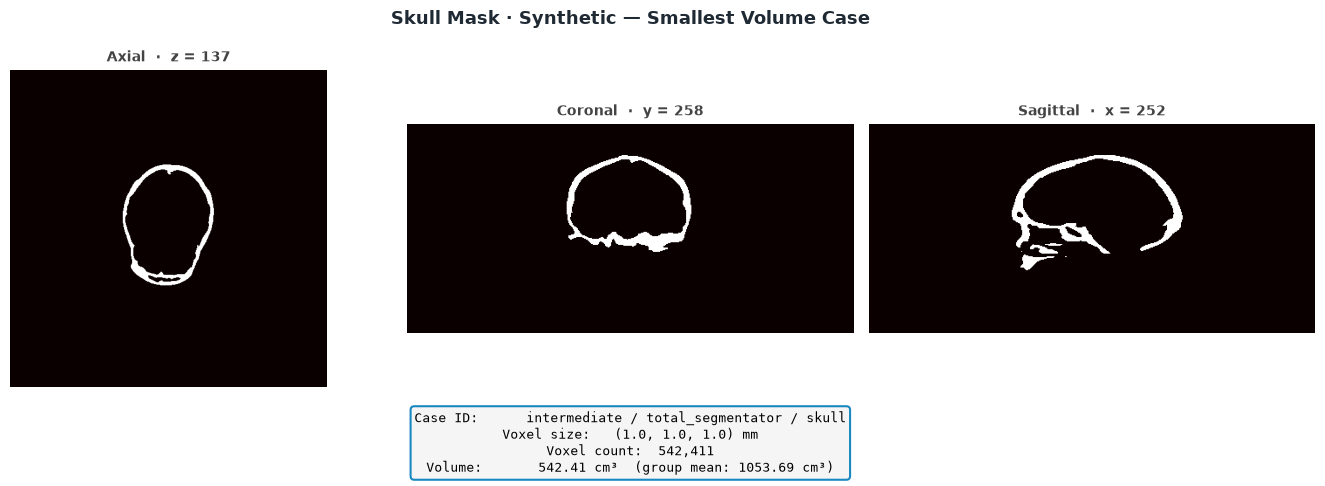

SAMPLE AND VOXEL SUMMARY
----------------------------------------------------------------------------------
Group            N Cases    Inverted     Avg Voxel Vol (mm³)       Avg Voxel Count
----------------------------------------------------------------------------------
Real                  63           0                0.232157             3,999,214
Synthetic            100           0                1.000000             1,053,695
----------------------------------------------------------------------------------

VOLUME DISTRIBUTION SUMMARY (cm³ unless otherwise noted)
--------------------------------------------------------------------------------------------------------------------------------------------
Group               Mean    Median   Std Dev  Variance (cm⁶)       Min        Q1        Q3       Max       IQR     Range    CV (%)      Skew
-----------------------------------------------------------------------------------------------------------------------------------------

In [5]:
for name, analysis in results.items():
    for figure_name, fig in analysis['figures'].items():
        print(f'--- {name} · {figure_name} ---')
        display(fig)
        plt.close(fig)

    print(analysis['summary_text'])
    print()


In [ ]:
for name, analysis in results.items():
    print(f'--- {name} ---')
    display(analysis['case_statistics'].head(10))

    if analysis['errors']:
        print(f"{len(analysis['errors'])} mask(s) failed to load:")

        for path, message in analysis['errors']:
            print(f'  {path} - {message}')


--- Brain Mask ---


,group,path,filename,case_id,inverted,voxel_volume_mm3,voxel_count,volume_cm3
0,Real,/projects01/didsr-aiml/yeelamelim.thompson/SDD...,no_brain.nii.gz,rsna_aneurysm / 1.2.826.0.1.3680043.8.498.1003...,True,0.157678,3516159,554.420351
1,Real,/projects01/didsr-aiml/yeelamelim.thompson/SDD...,no_brain.nii.gz,rsna_aneurysm / 1.2.826.0.1.3680043.8.498.1092...,True,0.109512,4330673,474.260651
2,Real,/projects01/didsr-aiml/yeelamelim.thompson/SDD...,no_brain.nii.gz,rsna_aneurysm / 1.2.826.0.1.3680043.8.498.1142...,True,0.305334,2160977,659.819948
3,Real,/projects01/didsr-aiml/yeelamelim.thompson/SDD...,no_brain.nii.gz,rsna_aneurysm / 1.2.826.0.1.3680043.8.498.1144...,True,0.136576,4512002,616.231146
4,Real,/projects01/didsr-aiml/yeelamelim.thompson/SDD...,no_brain.nii.gz,rsna_aneurysm / 1.2.826.0.1.3680043.8.498.1162...,True,0.149011,3929536,585.545922
5,Real,/projects01/didsr-aiml/yeelamelim.thompson/SDD...,no_brain.nii.gz,rsna_aneurysm / 1.2.826.0.1.3680043.8.498.1193...,True,0.095367,7355828,701.506434
6,Real,/projects01/didsr-aiml/yeelamelim.thompson/SDD...,no_brain.nii.gz,rsna_aneurysm / 1.2.826.0.1.3680043.8.498.1222...,True,0.154495,3477522,537.259045
7,Real,/projects01/didsr-aiml/yeelamelim.thompson/SDD...,no_brain.nii.gz,rsna_aneurysm / 1.2.826.0.1.3680043.8.498.1281...,True,0.149011,4402541,656.029090
8,Real,/projects01/didsr-aiml/yeelamelim.thompson/SDD...,no_brain.nii.gz,rsna_aneurysm / 1.2.826.0.1.3680043.8.498.1289...,True,0.081120,7650171,620.581851
9,Real,/projects01/didsr-aiml/yeelamelim.thompson/SDD...,no_brain.nii.gz,rsna_aneurysm / 1.2.826.0.1.3680043.8.498.1290...,True,0.092450,7988654,738.551087


--- Skull Mask ---


,group,path,filename,case_id,inverted,voxel_volume_mm3,voxel_count,volume_cm3
0,Real,/projects01/didsr-aiml/yeelamelim.thompson/SDD...,skull.nii.gz,intermediate / total_segmentator / skull,False,0.157678,3600415,567.705655
1,Real,/projects01/didsr-aiml/yeelamelim.thompson/SDD...,skull.nii.gz,intermediate / total_segmentator / skull,False,0.109512,5116692,560.339162
2,Real,/projects01/didsr-aiml/yeelamelim.thompson/SDD...,skull.nii.gz,intermediate / total_segmentator / skull,False,0.147920,82002,12.129736
3,Real,/projects01/didsr-aiml/yeelamelim.thompson/SDD...,skull.nii.gz,intermediate / total_segmentator / skull,False,0.305334,1651640,504.301998
4,Real,/projects01/didsr-aiml/yeelamelim.thompson/SDD...,skull.nii.gz,intermediate / total_segmentator / skull,False,0.136576,5025755,686.397471
5,Real,/projects01/didsr-aiml/yeelamelim.thompson/SDD...,skull.nii.gz,intermediate / total_segmentator / skull,False,0.149011,3816978,568.773489
6,Real,/projects01/didsr-aiml/yeelamelim.thompson/SDD...,skull.nii.gz,intermediate / total_segmentator / skull,False,0.095367,7676384,732.077037
7,Real,/projects01/didsr-aiml/yeelamelim.thompson/SDD...,skull.nii.gz,intermediate / total_segmentator / skull,False,0.154495,4639844,716.831743
8,Real,/projects01/didsr-aiml/yeelamelim.thompson/SDD...,skull.nii.gz,intermediate / total_segmentator / skull,False,0.149011,2966548,442.049668
9,Real,/projects01/didsr-aiml/yeelamelim.thompson/SDD...,skull.nii.gz,intermediate / total_segmentator / skull,False,0.081120,6795649,551.263028


## 5 · Saved outputs


In [7]:
for name, analysis in results.items():
    for path in analysis['saved_paths']:
        print(path)


/home/alexander.webber/programming/ScoreCard-Private/notebooks/data/notebook_outputs/brain_masks/Brain_Mask_comparison.svg
/home/alexander.webber/programming/ScoreCard-Private/notebooks/data/notebook_outputs/brain_masks/Brain_Mask_volume_distribution.svg
/home/alexander.webber/programming/ScoreCard-Private/notebooks/data/notebook_outputs/brain_masks/Brain_Mask_smallest_Real.svg
/home/alexander.webber/programming/ScoreCard-Private/notebooks/data/notebook_outputs/brain_masks/Brain_Mask_smallest_Synthetic.svg
/home/alexander.webber/programming/ScoreCard-Private/notebooks/data/notebook_outputs/brain_masks/Brain_Mask_case_statistics.csv
/home/alexander.webber/programming/ScoreCard-Private/notebooks/data/notebook_outputs/brain_masks/Brain_Mask_summary.csv
/home/alexander.webber/programming/ScoreCard-Private/notebooks/data/notebook_outputs/brain_masks/Brain_Mask_summary.txt
/home/alexander.webber/programming/ScoreCard-Private/notebooks/data/notebook_outputs/brain_masks/Skull_Mask_comparison.s